# [LAB-02] 5. 계층적 군집(Hierarchical Clustering)

## #01. 준비작업

### 1. 패키지 가져오기

In [1]:
from jussam import load_data
from helpers import *

# 군집분석 관련 참조
from sklearn.cluster import AgglomerativeClustering

# 덴드로그램
from scipy.cluster.hierarchy import dendrogram

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### [2] 데이터 가져오기

In [2]:
origin = load_data("game_usage")
origin.head()

📚 게임 이용시간(time spent)과 레벨(game level)에 대한 가상 데이터


,time spent,game level
0,39,944
1,55,705
2,29,757
3,59,999
4,7,109


### [3] 데이터 스케일링

In [3]:
sdf = my_prep.scaling(origin, method="standard", verbose=False)
sdf.head()

,time spent,game level
0,-0.251,1.475
1,0.326,0.607
2,-0.612,0.795
3,0.471,1.675
4,-1.405,-1.559


## #02. 군집 수행

### 1. 군집 모델 구현

In [4]:
# 방법 1) 개수를 직접 지정하는 경우
# estimator = AgglomerativeClustering(n_clusters=4, compute_distances=True)

# 방법 2) 거리 기준으로 자동 결정 (여기서는 이 방법을 사용)
estimator = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=5,     # 거리 5보다 멀면 합치지 않는다
    compute_distances=True,   # 덴드로그램을 그리려면 반드시 True
)

estimator.fit(sdf)

result_df = sdf.copy()
result_df["cluster"] = estimator.labels_

print(f"만들어진 군집 수: {estimator.n_clusters_}개")
result_df.head()

만들어진 군집 수: 5개


,time spent,game level,cluster
0,-0.251,1.475,0
1,0.326,0.607,0
2,-0.612,0.795,2
3,0.471,1.675,0
4,-1.405,-1.559,4


### 2. 군집 결과 시각화

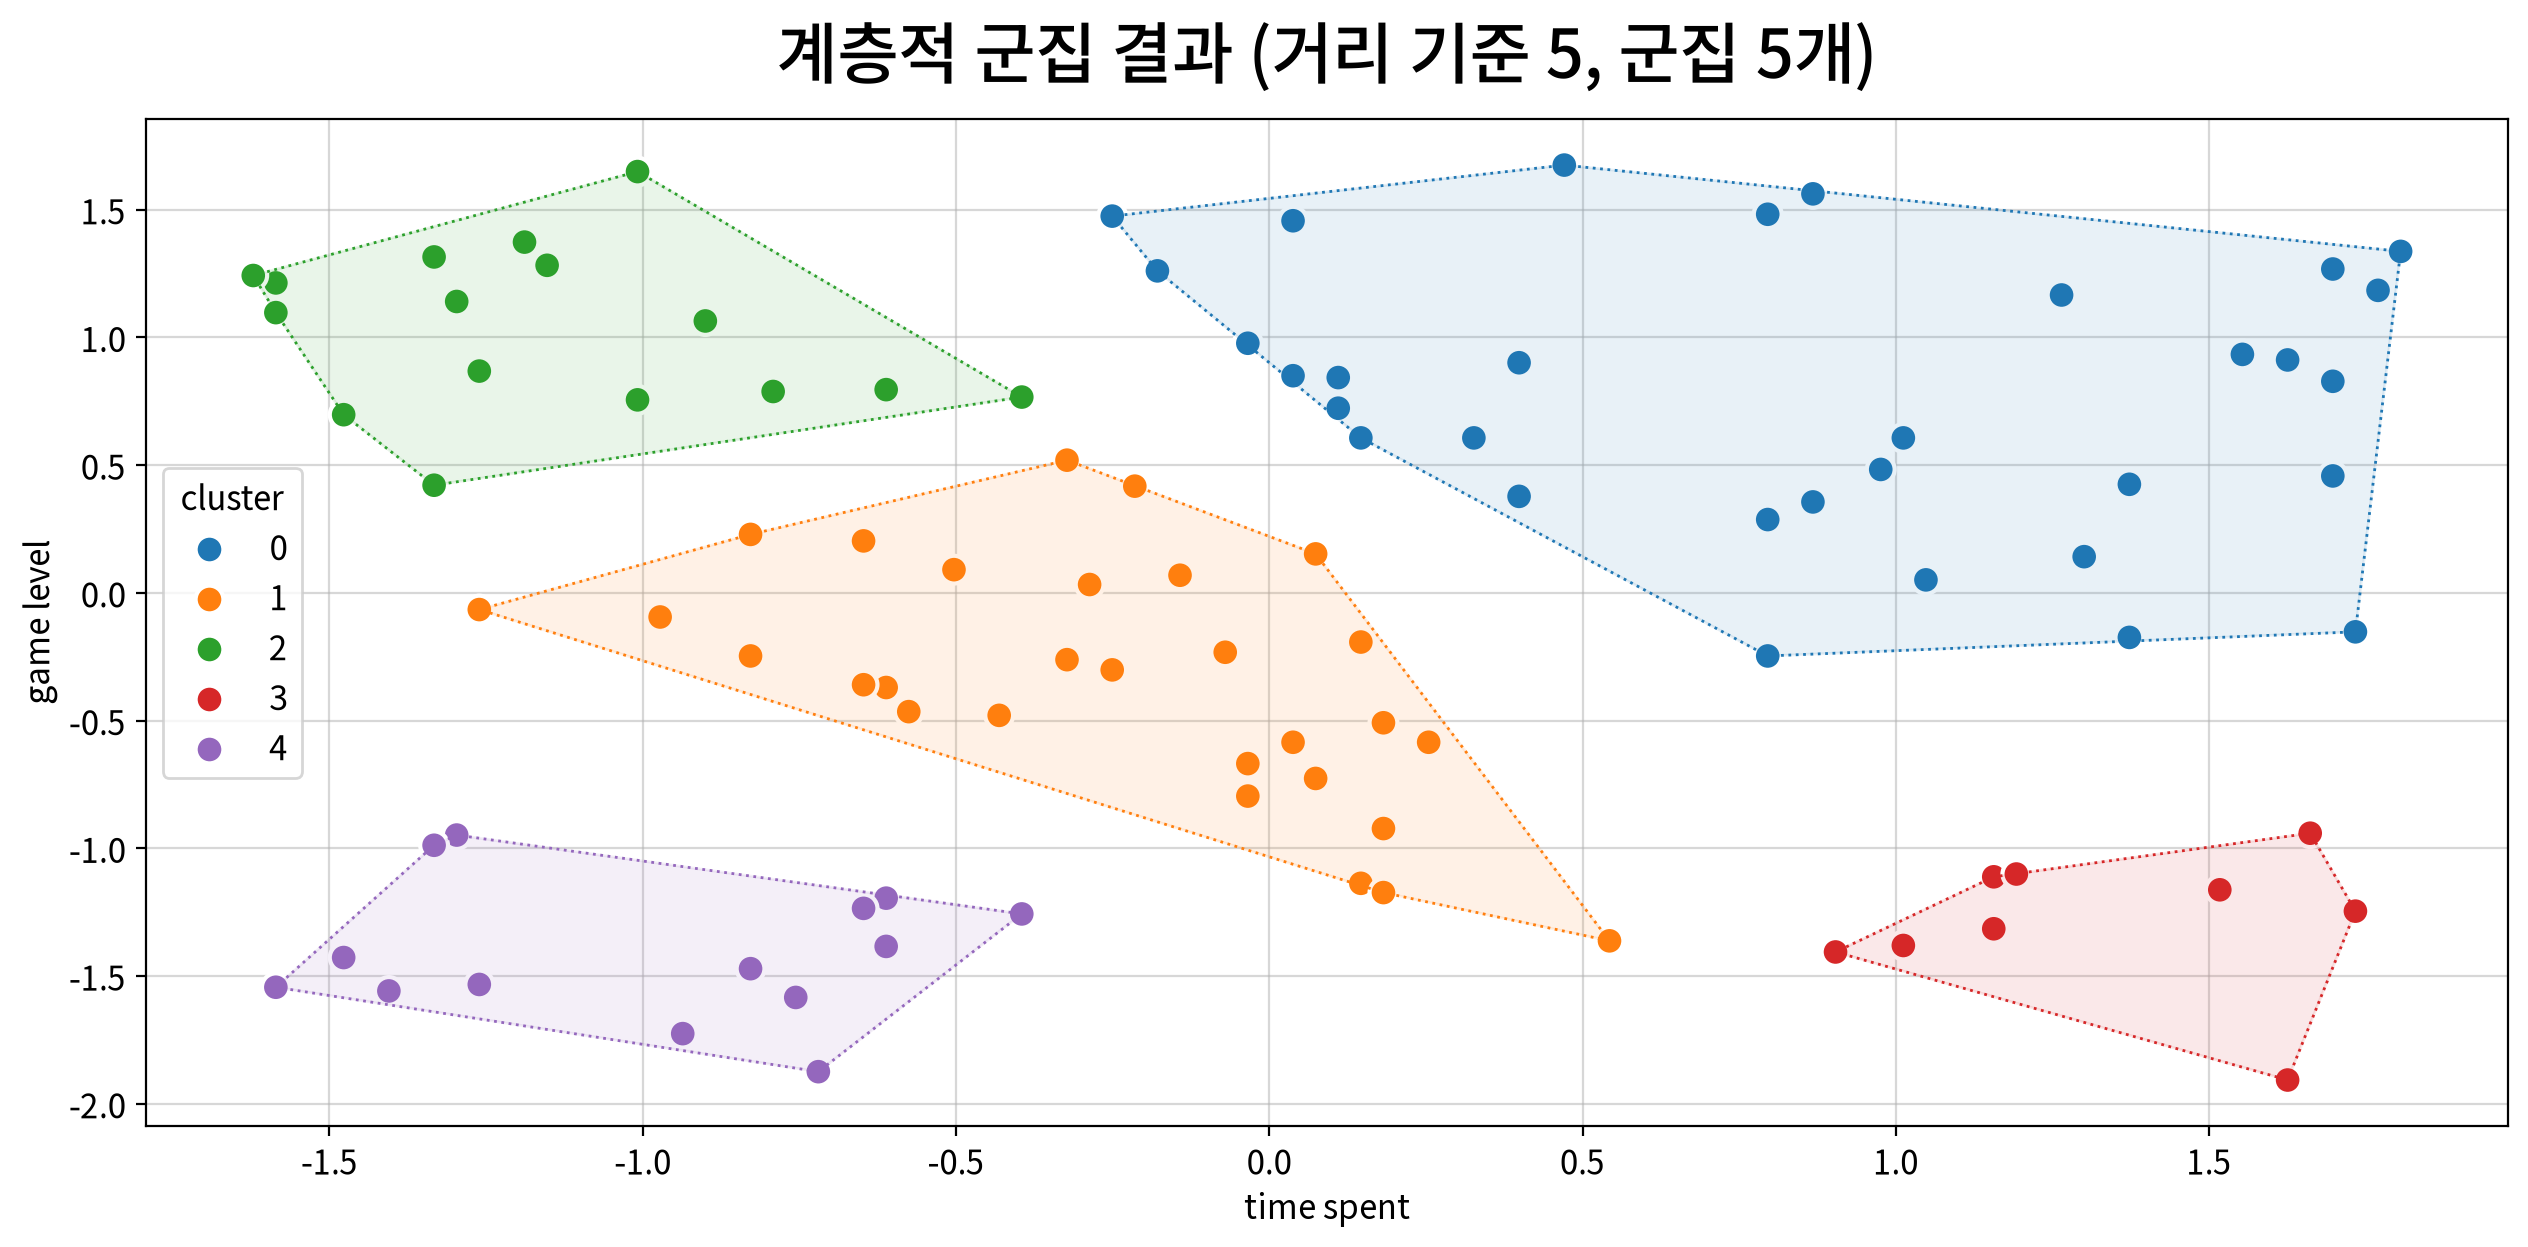

In [5]:
my_plot.scatterplot(data=result_df, x="time spent", y="game level", hue="cluster",
                    outline=True,
                    title=f"계층적 군집 결과 (거리 기준 5, 군집 {estimator.n_clusters_}개)")

### 3. 실루엣 지수로 결과 확인

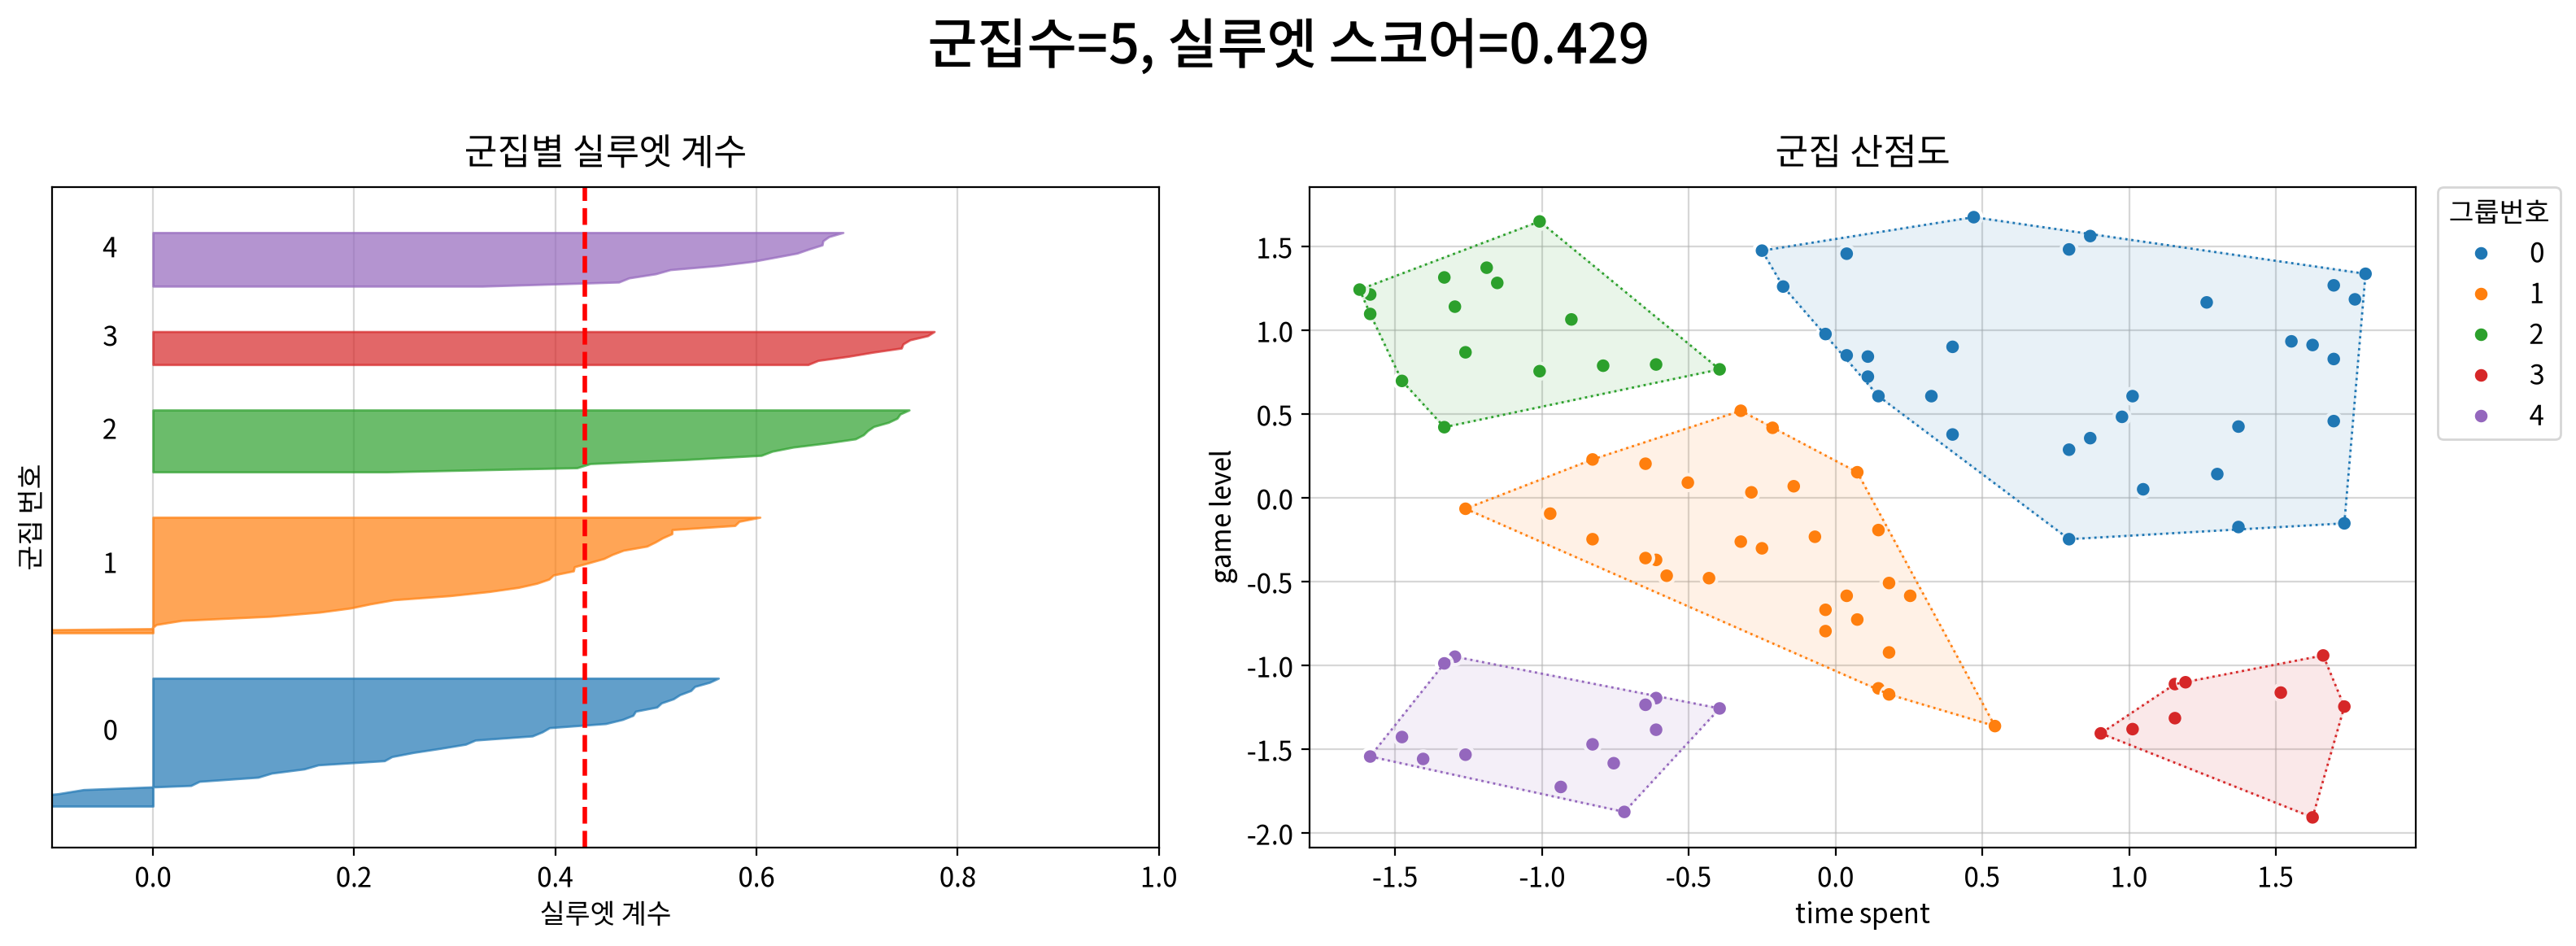

In [6]:
my_cluster.visualize_silhouette(estimator=estimator, data=sdf)

> 실루엣 점수가 그리 높지는 않다.
>
> 실루엣은 **동글동글한 그룹**을 전제로 만든 지표라서, 모양이 복잡한 군집에는 잘 맞지 않는다.
> 그래서 점수만 믿지 말고 **그림을 함께 보고 분석가가 판단**해야 한다.

## #03. 덴드로그램

### 1. 덴드로그램용 데이터 만들기

sklearn에는 덴드로그램을 바로 그리는 기능이 없어서, 모델이 가진 정보를 조합해 주는 함수가 필요하다.

In [7]:
data = my_cluster.dendrogram_source(estimator)
data[:5]

array([[3.60000000e+01, 8.70000000e+01, 3.76869846e-02, 2.00000000e+00],
       [5.10000000e+01, 9.80000000e+01, 3.76869846e-02, 2.00000000e+00],
       [2.50000000e+01, 4.20000000e+01, 4.63269855e-02, 2.00000000e+00],
       [8.00000000e+00, 3.70000000e+01, 5.11987456e-02, 2.00000000e+00],
       [1.20000000e+01, 1.70000000e+01, 5.38374037e-02, 2.00000000e+00]])

### [3] 덴드로그램 시각화

| 파라미터 | 의미 | ⭐ 추천값 |
|---|---|---|
| `data` | 위에서 만든 병합 정보 | 필수 |
| `truncate_mode` | 너무 빽빽할 때 줄여서 표시 | **`'lastp'`** |
| `p` | `lastp` 와 함께 — 마지막 몇 개까지 보여줄지 | **20~50** |
| `leaf_rotation` | X축 글자 회전 각도 | `0` 또는 `90` |
| `leaf_font_size` | X축 글자 크기 | `6~10` |
| `count_sort` | 가지의 정렬 순서 | `'ascending'` |

- **`truncate_mode`**
    - `None` : 전체를 다 그린다 (데이터가 많으면 읽을 수 없다)
    - **`'lastp'`** ⭐ : 마지막 `p`개의 가지만 보여준다. X축에 `(3)`, `(5)` 처럼 **묶인 개수**가 표시된다

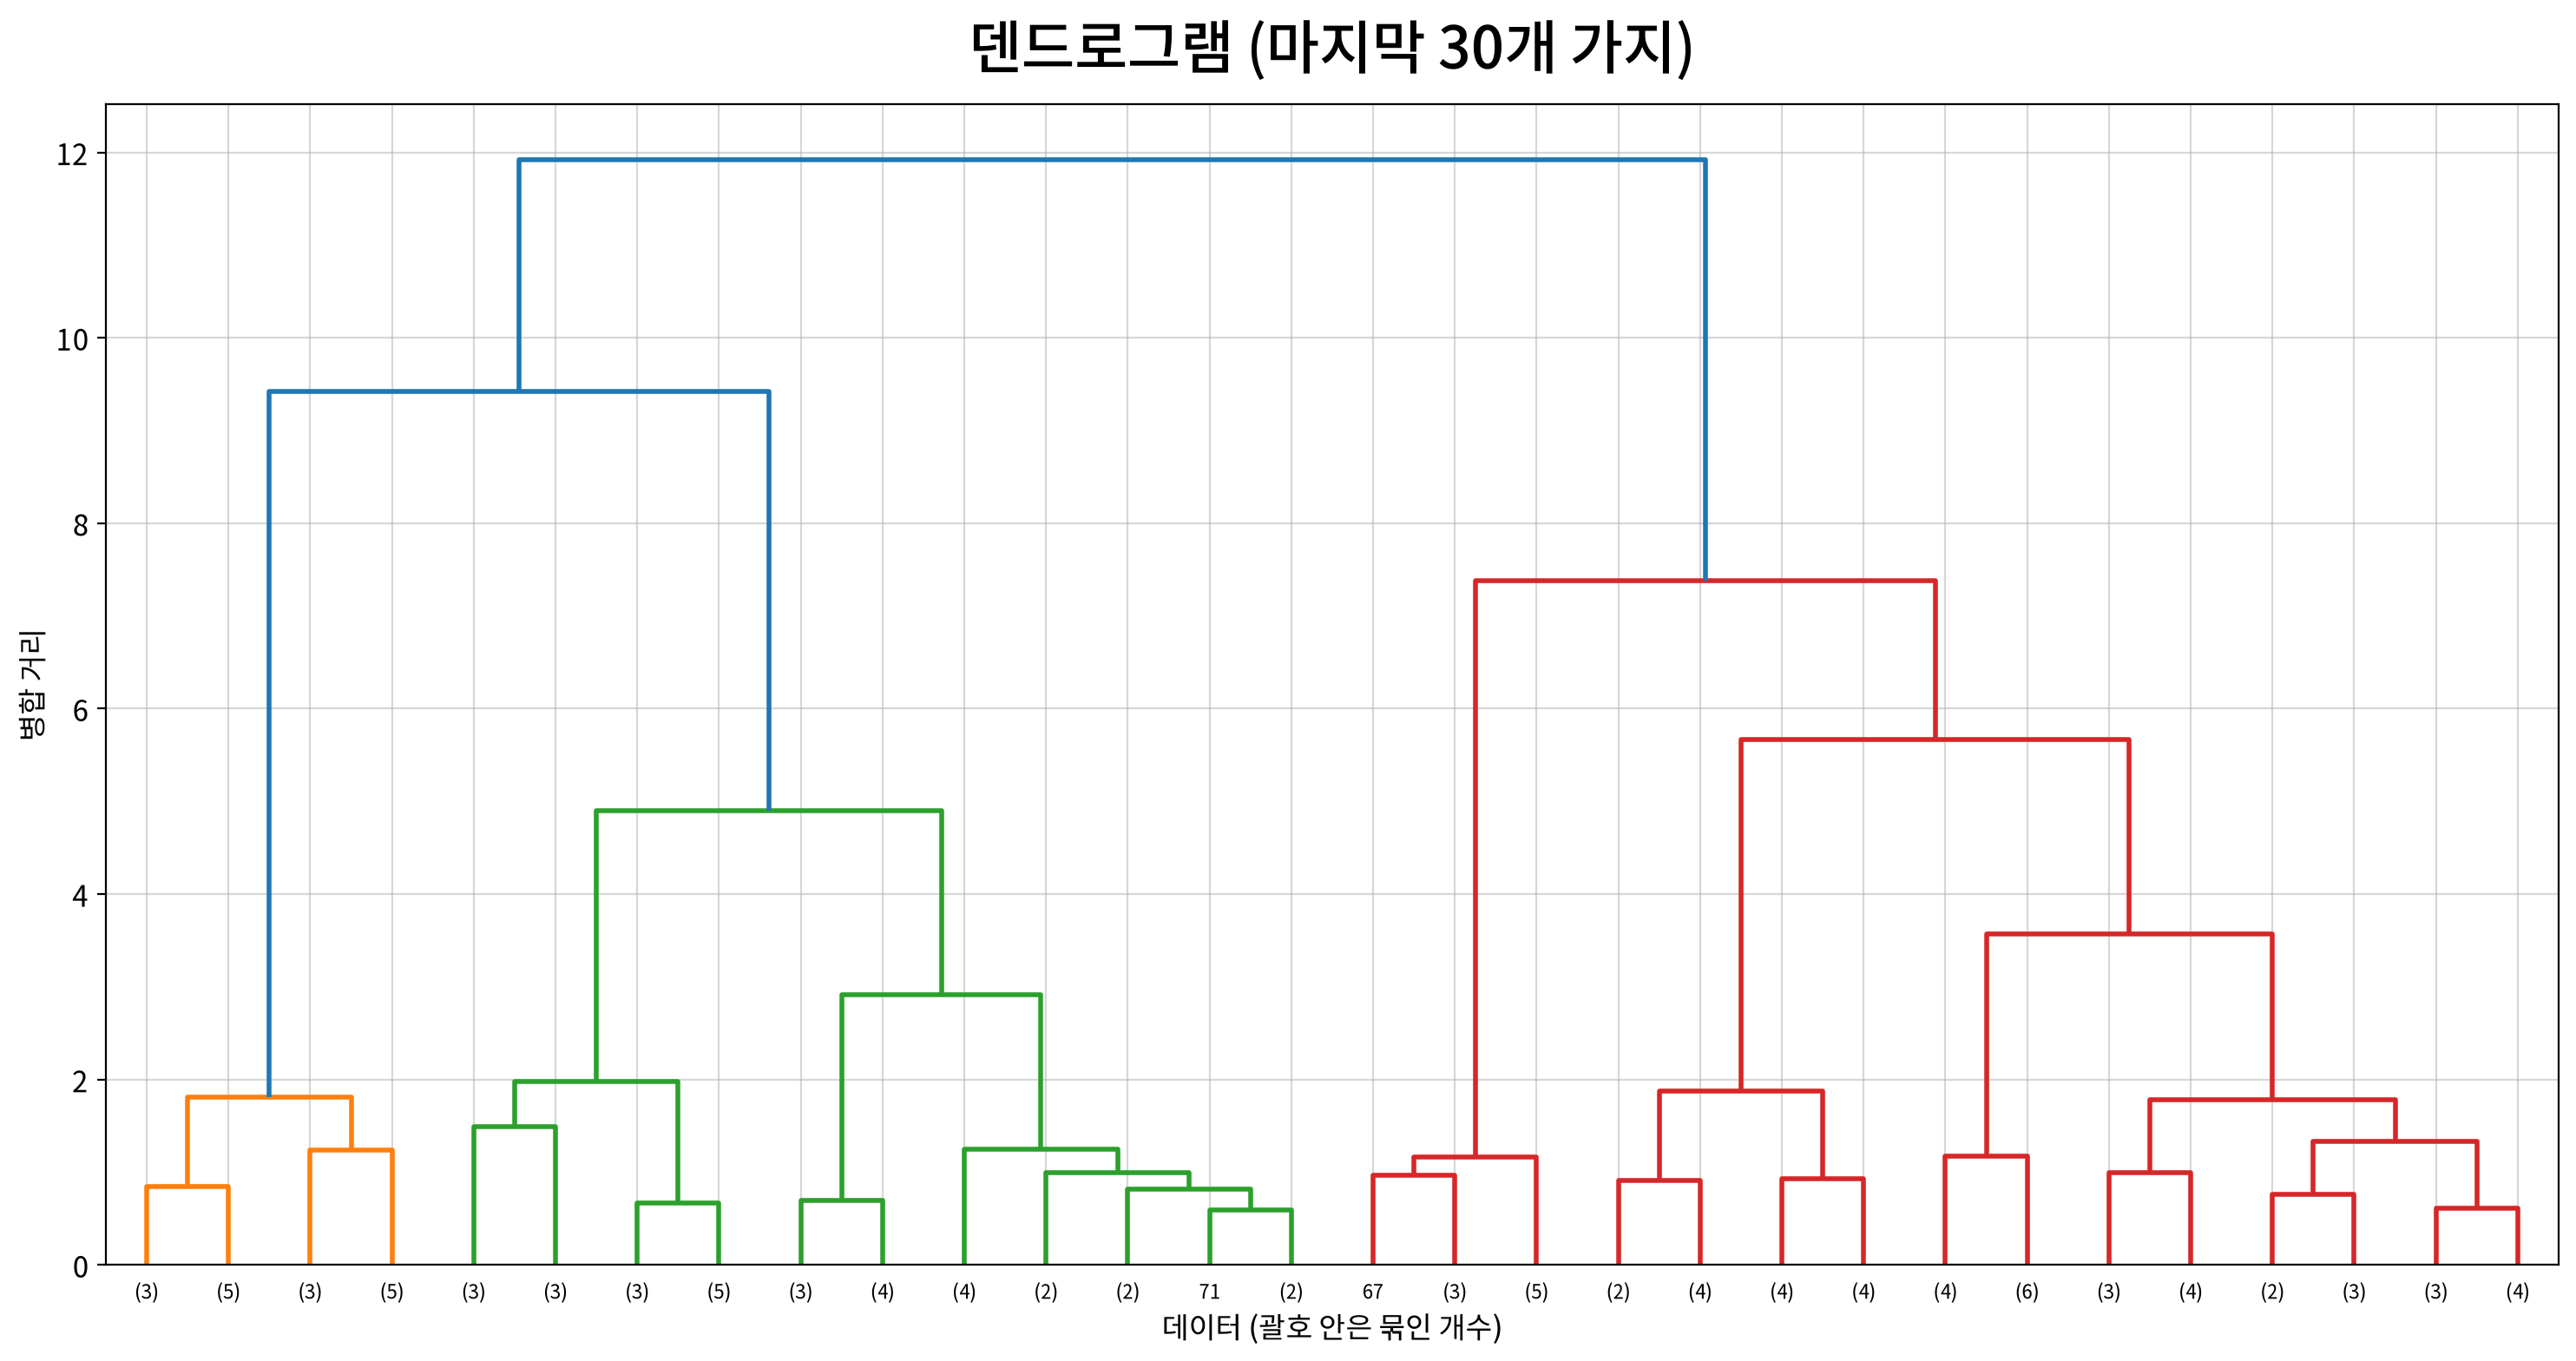

In [8]:
fig, ax = my_plot.init(width=1500, height=800, title="덴드로그램 (마지막 30개 가지)")

dendrogram(
    data,
    ax=ax,
    p=30,
    truncate_mode="lastp",
    leaf_rotation=0,
    leaf_font_size=8,
    count_sort="ascending",
)

ax.set_xlabel("데이터 (괄호 안은 묶인 개수)")
ax.set_ylabel("병합 거리")

my_plot.show()

#### `x` 축 해석

덴드로그램 X축의 괄호 숫자는 **"이 가지 아래에 데이터가 몇 개 들어 있나"** 를 뜻한다.

| X축 표시 | 의미 |
| --- | --- |
| `3` | 3번 데이터 1개 (개별 샘플) |
| `(3)` | 데이터 **3개가 이미 묶인** 그룹 |
| `(5)` | 데이터 **5개가 묶인** 그룹 |

처음에는 모든 데이터가 개별 노드라서 괄호가 없지만, 병합이 진행되면 **대표 노드 + (포함된 개수)** 로 표시된다.

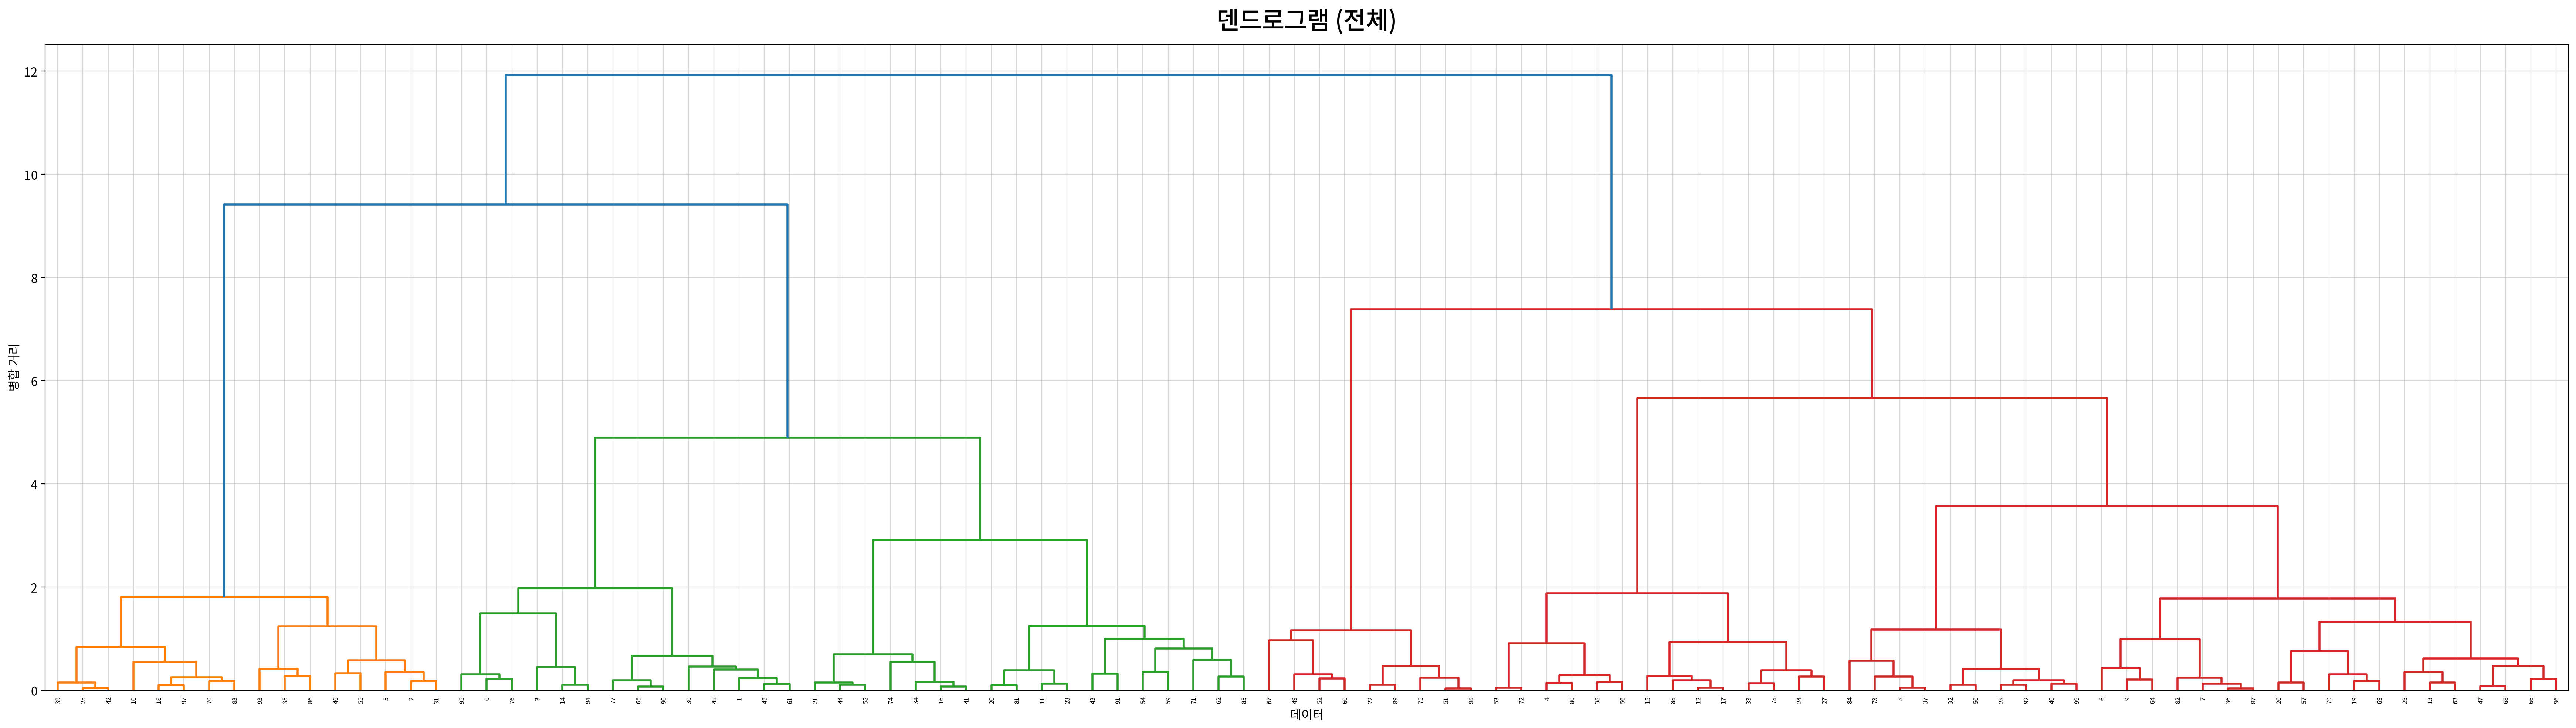

In [9]:
fig, ax = my_plot.init(width=3500, height=1000, title="덴드로그램 (전체)")

dendrogram(
    data,
    ax=ax,
    truncate_mode=None,   # p를 무시하고 전체를 표시
    leaf_rotation=90,
    leaf_font_size=6,
    count_sort="ascending",
)

ax.set_xlabel("데이터")
ax.set_ylabel("병합 거리")

my_plot.show()

## #04. 모듈화 기능 확인

### 1. 덴드로그램

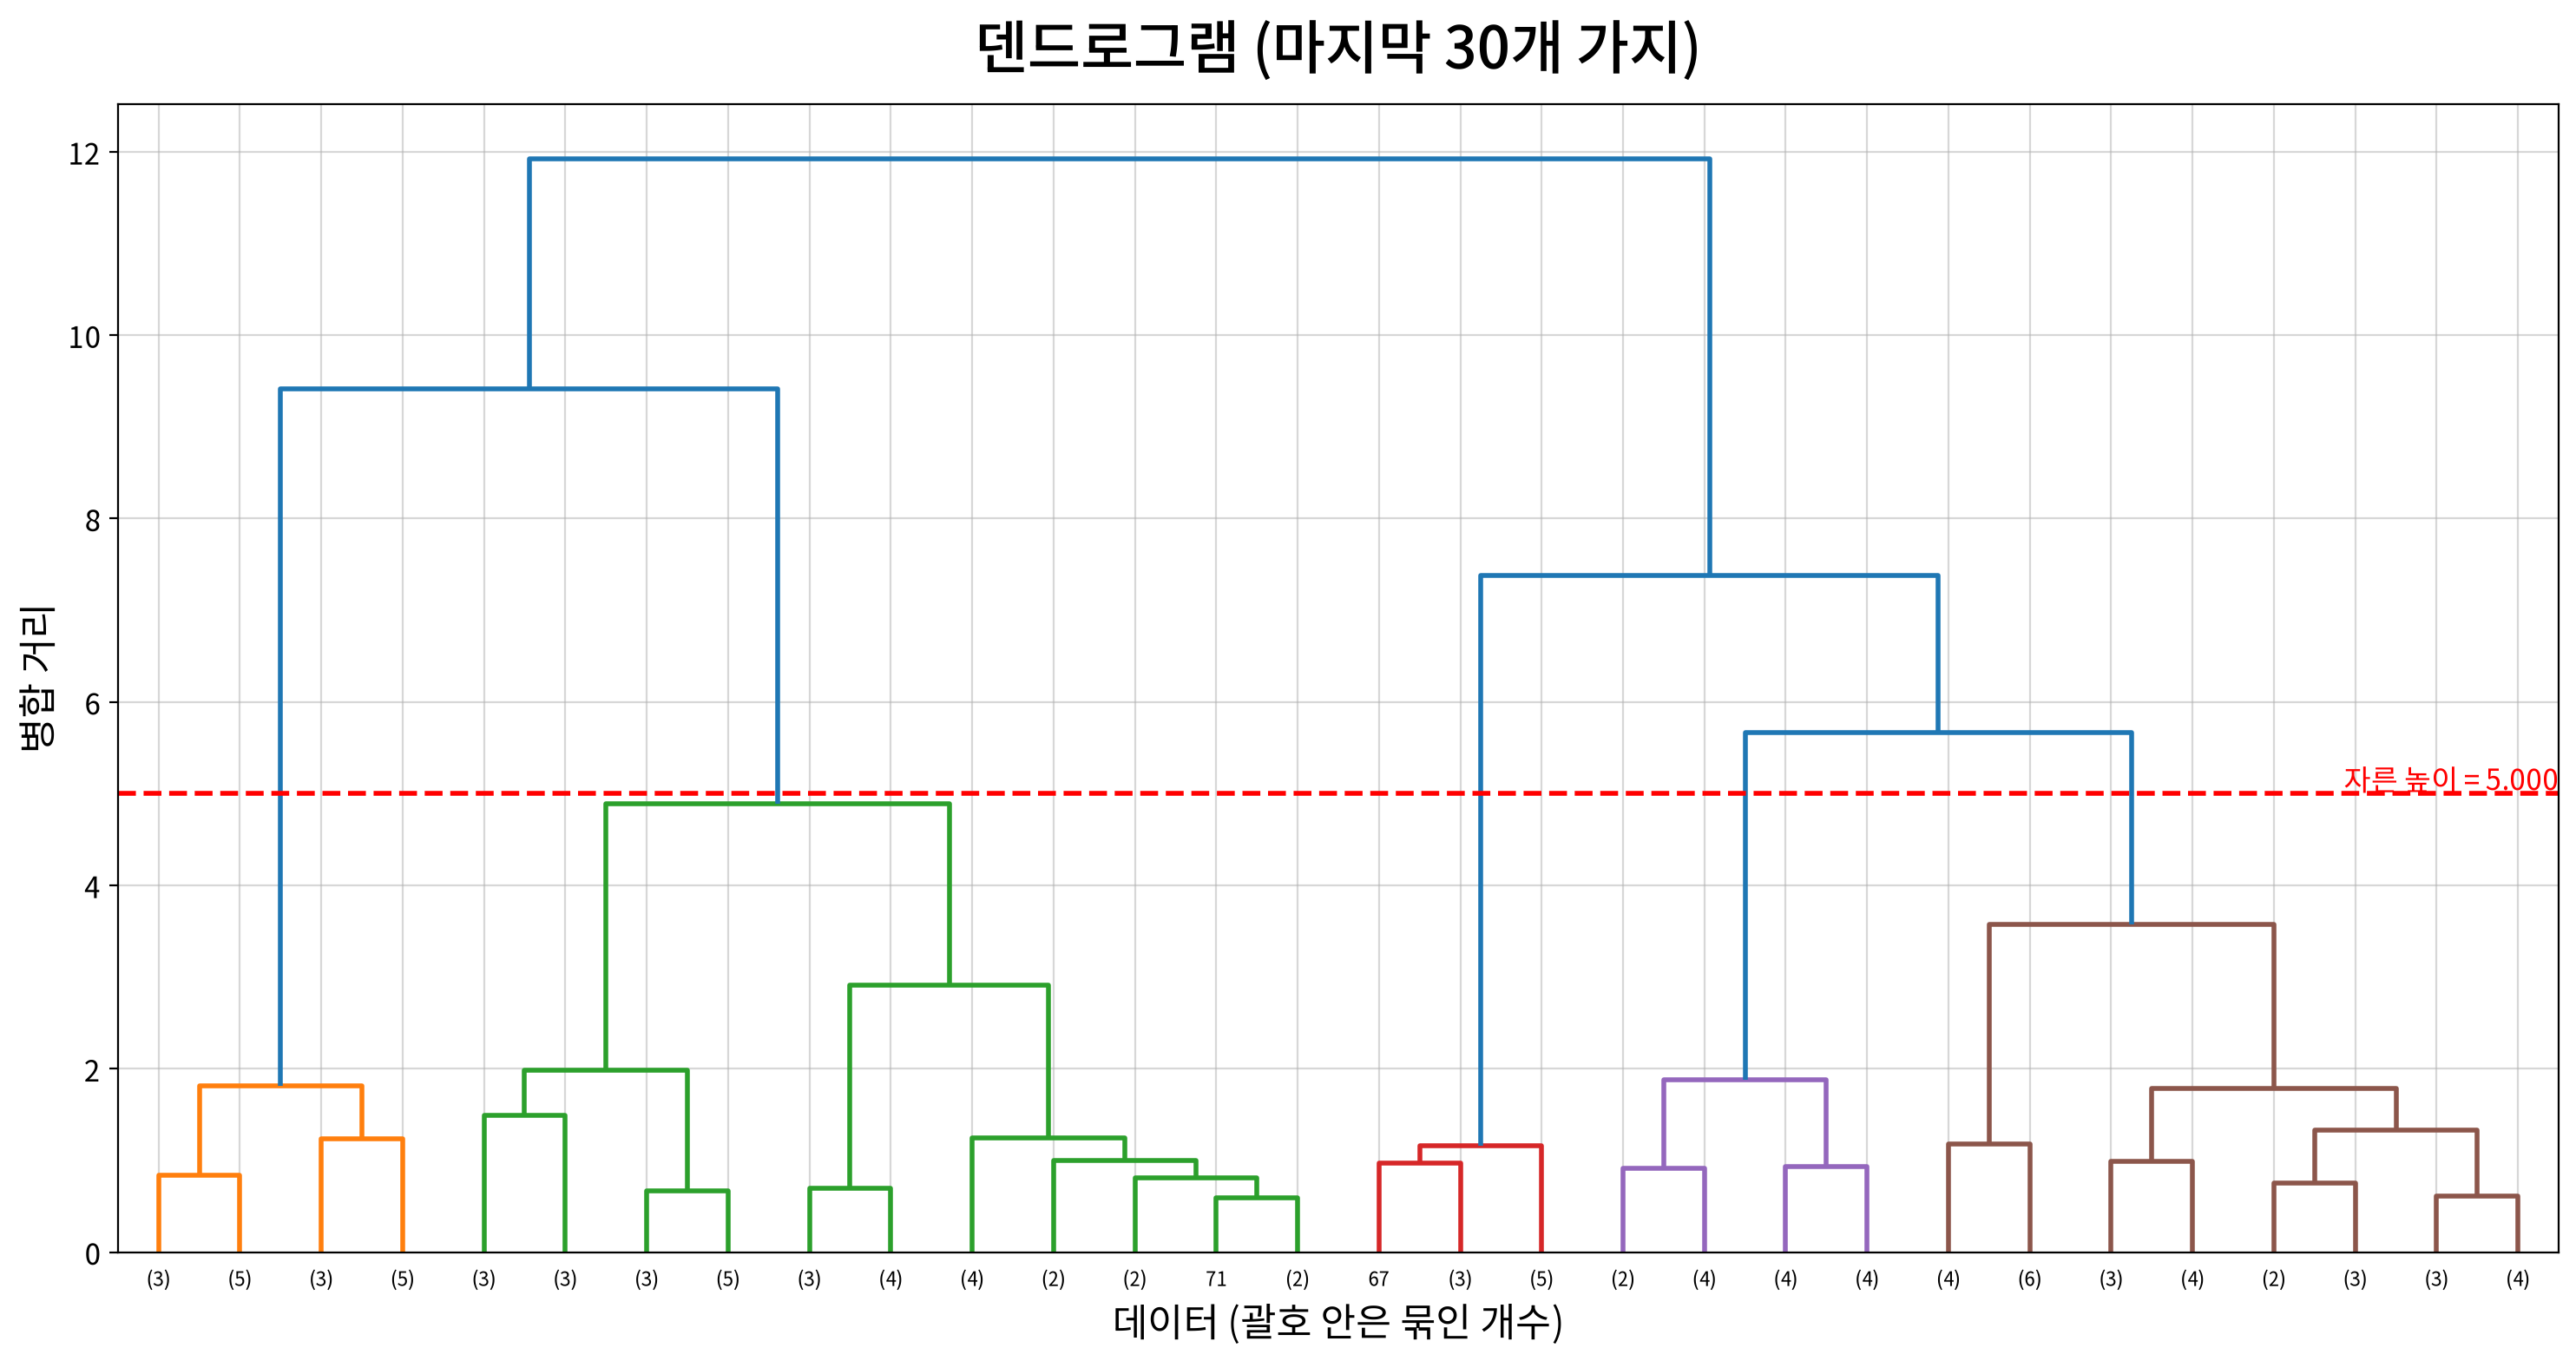

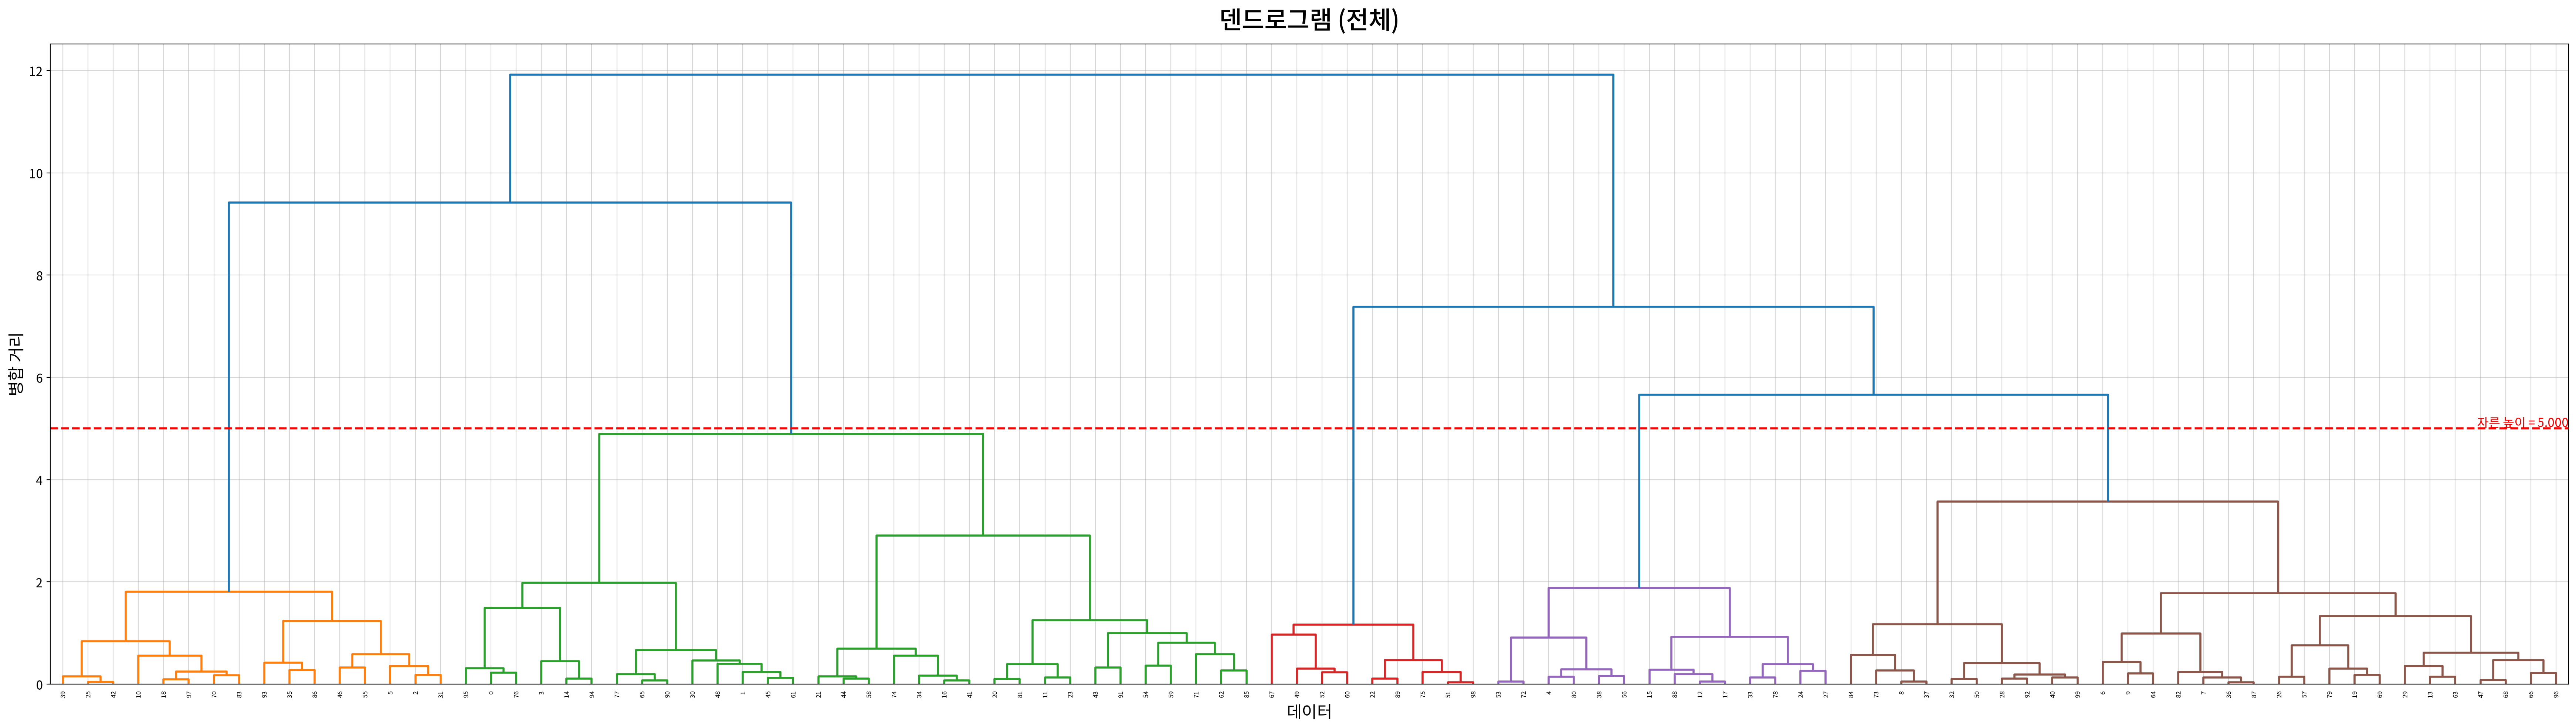

In [10]:
# #03에서 한 일(linkage 행렬 만들기 → 캔버스 생성 → 그리기 → 축 이름 지정)을
# 모듈화 함수 하나가 대신한다
my_cluster.plot_dendrogram(estimator, title="덴드로그램 (마지막 30개 가지)",
                                width=1500, height=800)

# 전체를 보고 싶다면 가지를 생략하지 않도록 truncate_mode 를 None 으로 지정한다
my_cluster.plot_dendrogram(estimator, truncate_mode=None,
                                leaf_rotation=90, leaf_font_size=6,
                                title="덴드로그램 (전체)", width=3500, height=1000)

### 2. 거리 기준으로 자동 결정 (#02 와 같은 조건)

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00          -1.62 ~ 1.81
game level        13.00 ~ 999.00          -1.91 ~ 1.67
[계층적 군집] 군집 수 = 5, 연결 방법 = ward, 거리 = euclidean
  · 자른 높이(병합 거리) = 5.0000
  · 군집별 데이터 개수 : 0번 32개, 1번 29개, 2번 16개, 3번 9개, 4번 14개


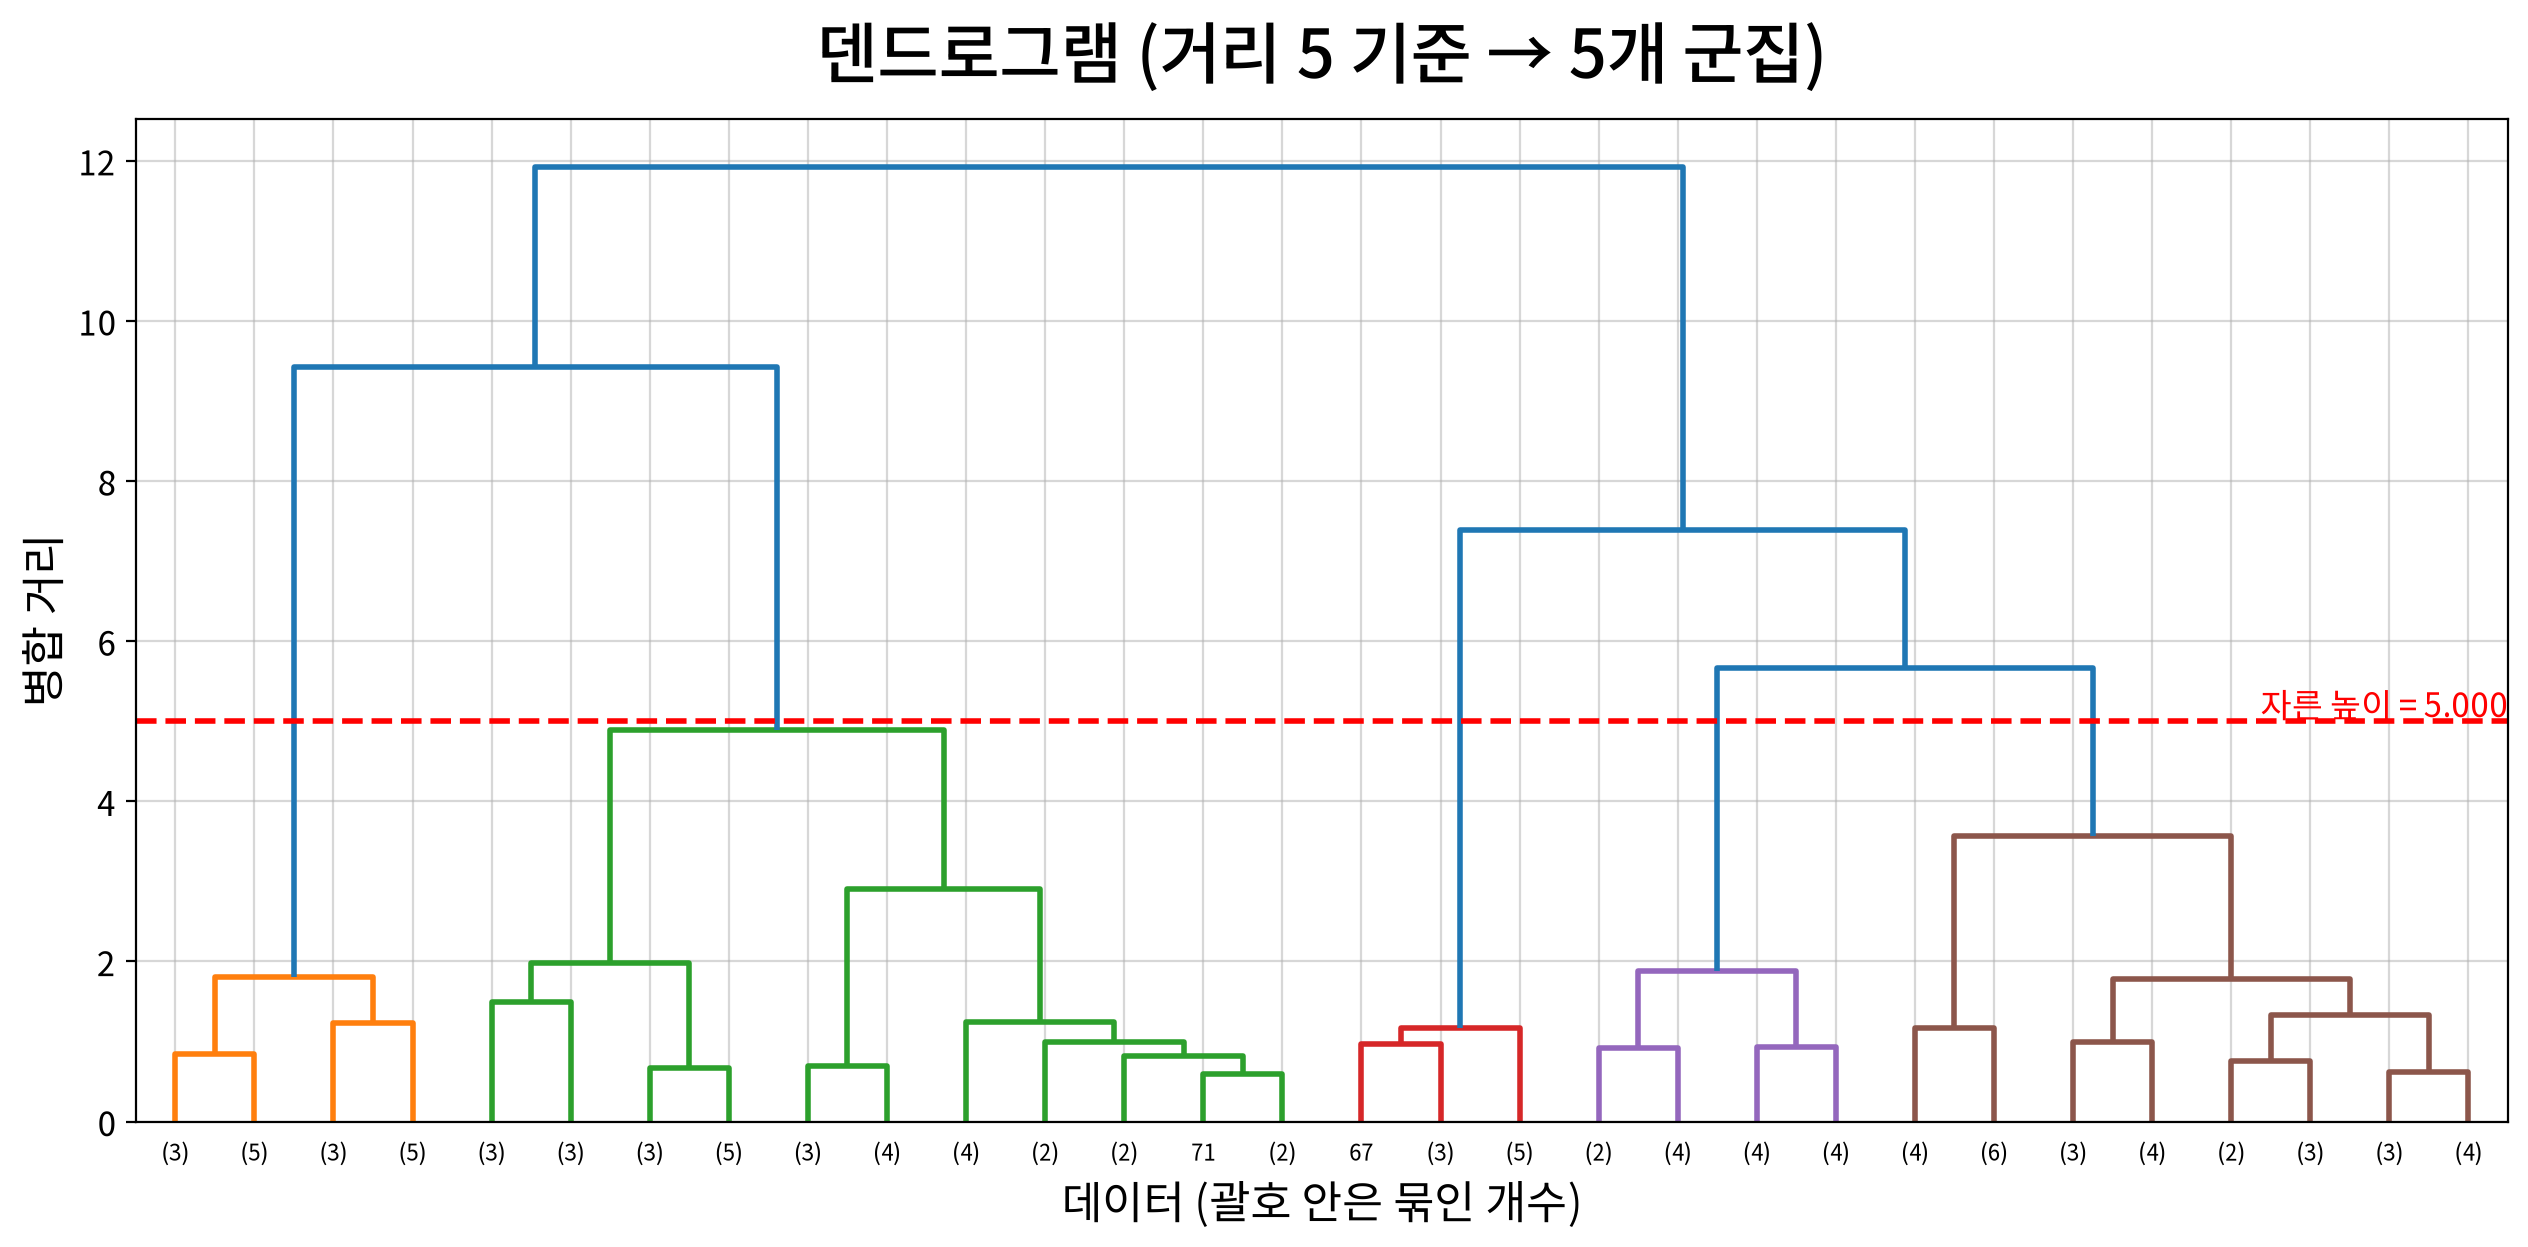

,time spent,game level,그룹번호
0,-0.251,1.475,0
1,0.326,0.607,0
2,-0.612,0.795,2
3,0.471,1.675,0
4,-1.405,-1.559,4


In [11]:
# 스케일링(기본값 standard)까지 함수가 알아서 수행한다
estimator, df = my_cluster.agglomerative(origin, distance_threshold=5)
df.head()

> 덴드로그램의 빨간 점선이 **자른 높이(거리 5)** 다. 이 선과 만나는 가지의 수가 곧 군집 수가 된다.

### 3. 군집 수를 직접 지정

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00          -1.62 ~ 1.81
game level        13.00 ~ 999.00          -1.91 ~ 1.67
[계층적 군집] 군집 수 = 4, 연결 방법 = ward, 거리 = euclidean
  · 자른 높이(병합 거리) = 6.5230
  · 군집별 데이터 개수 : 0번 43개, 1번 32개, 2번 16개, 3번 9개


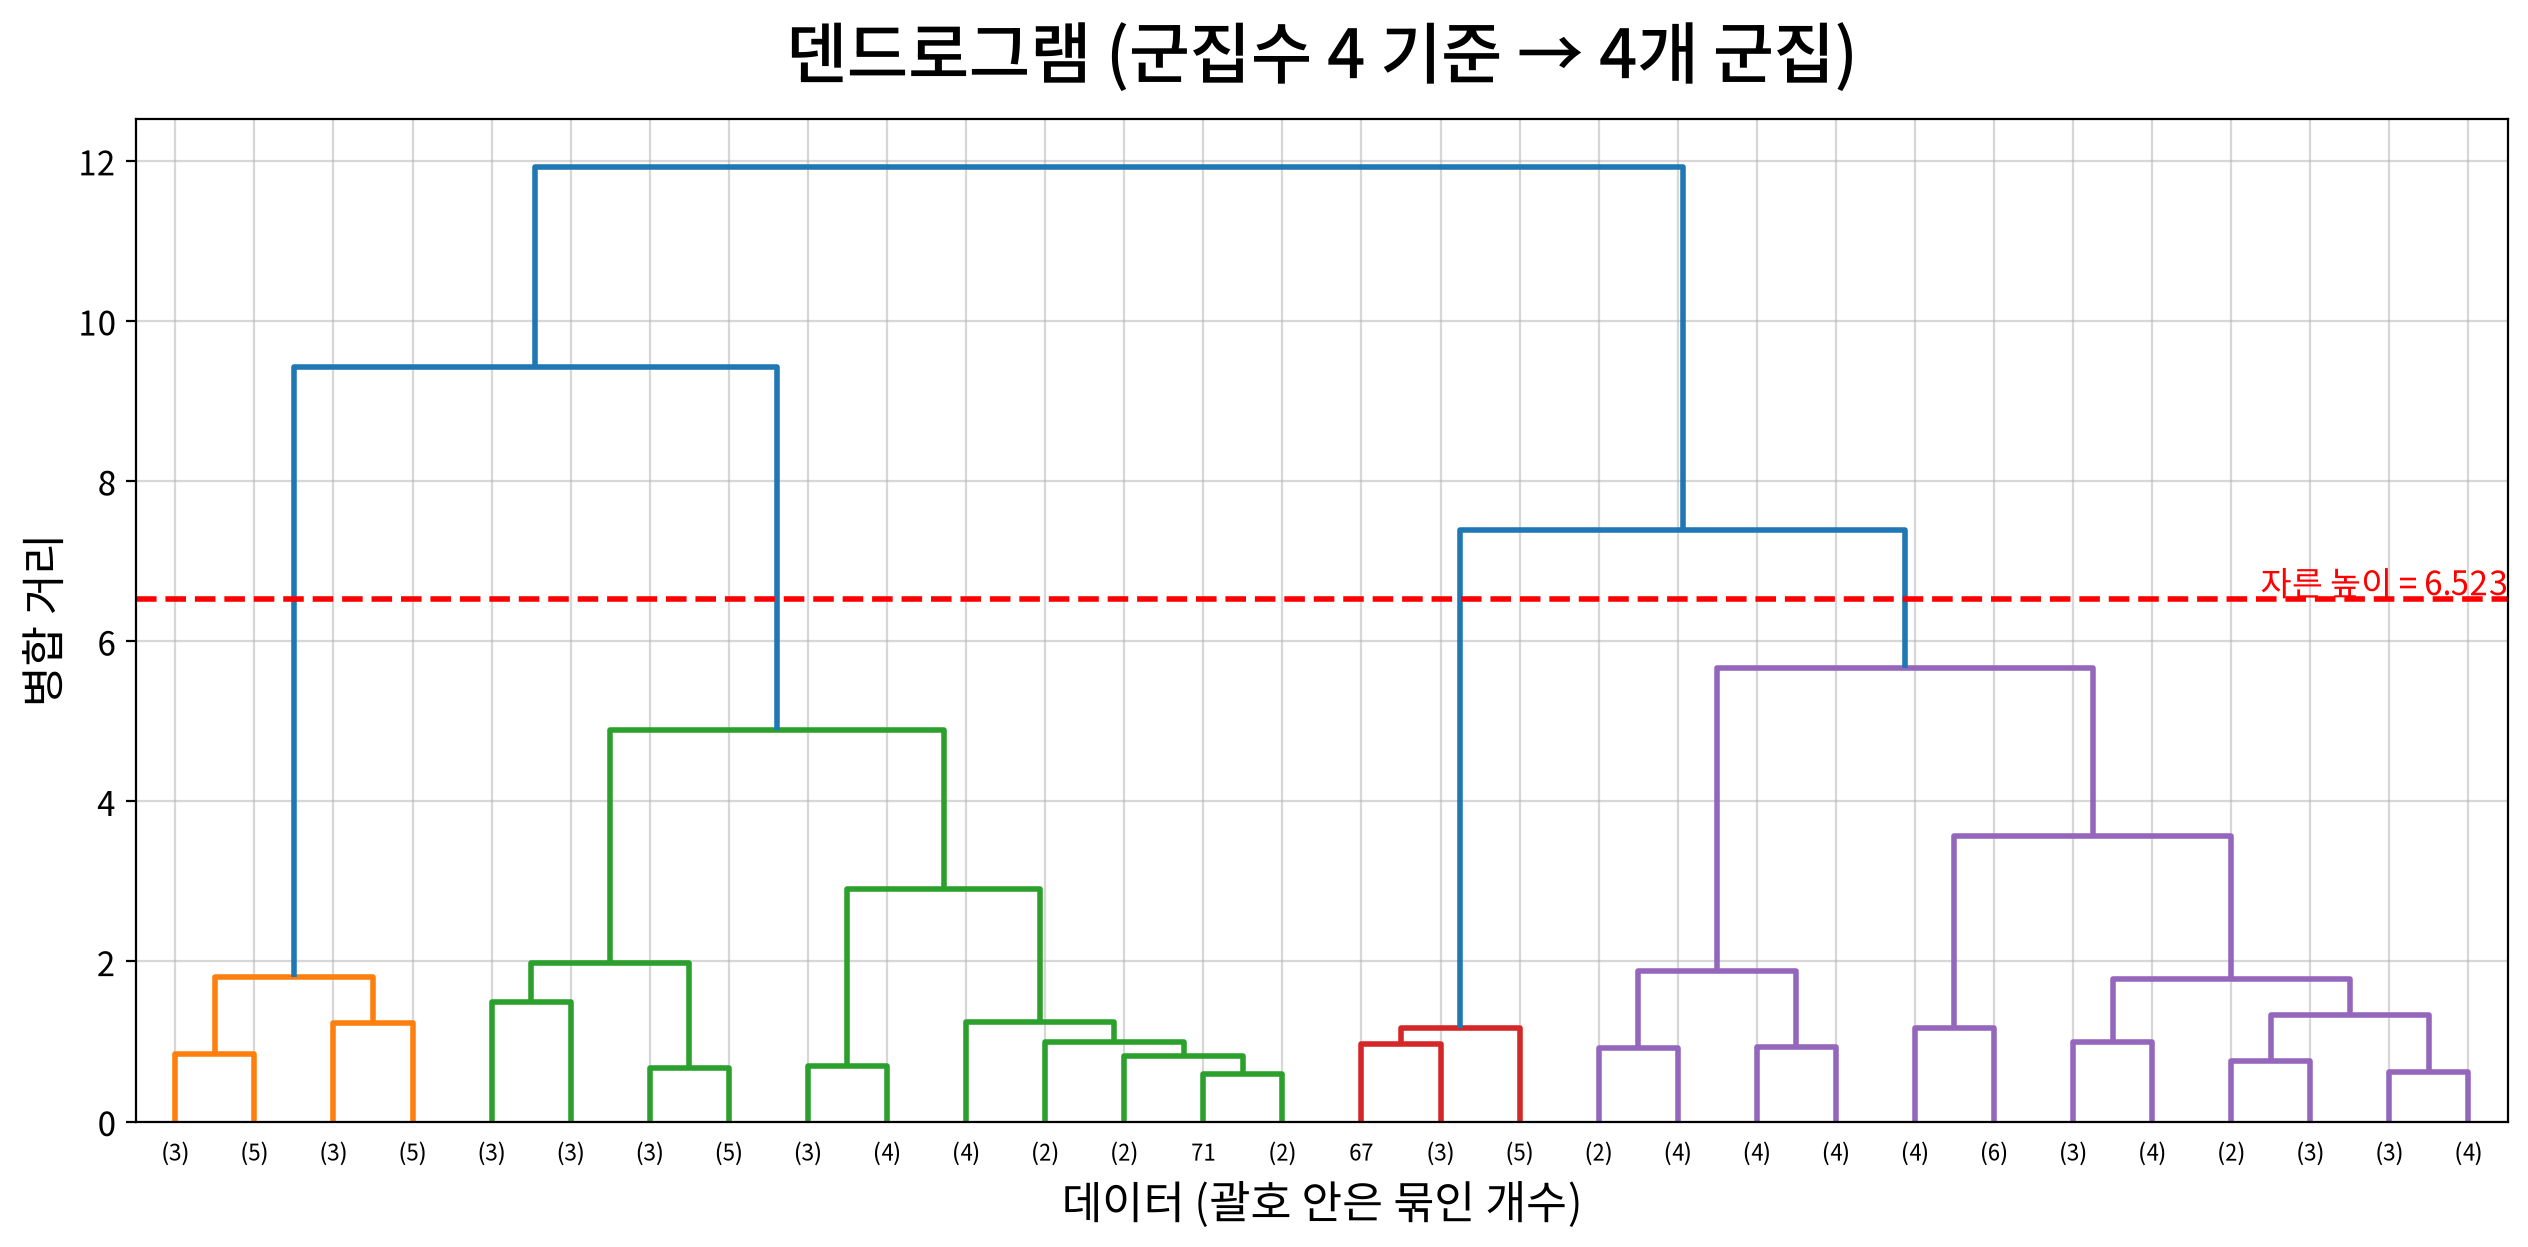

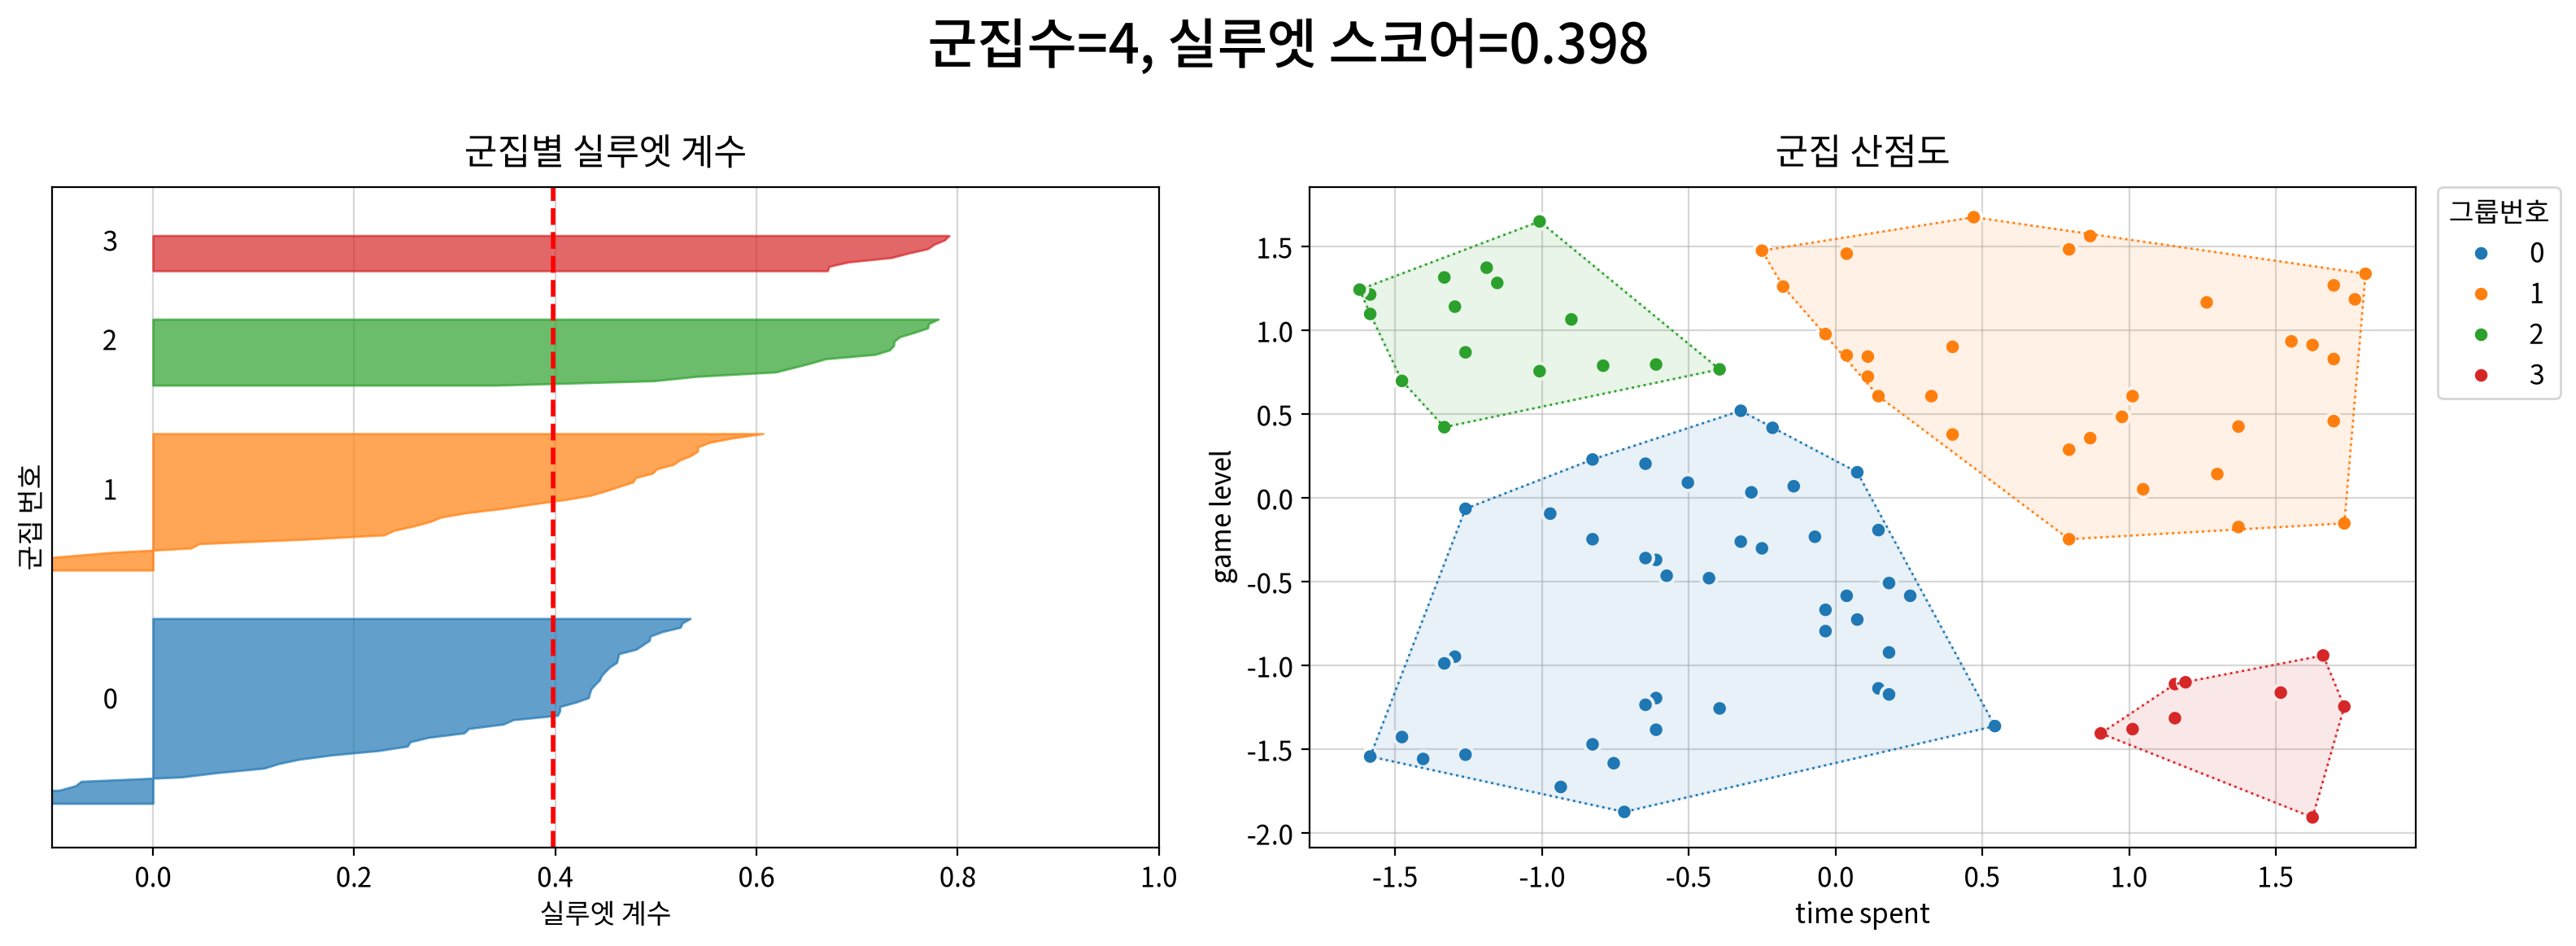

In [12]:
estimator, df = my_cluster.agglomerative(origin, k=4)

# 실루엣 지수도 함께 확인 (군집번호 컬럼은 함수가 알아서 제외한다)
my_cluster.visualize_silhouette(estimator=estimator, data=df)

### 4. 연결 방법 변경 + 덴드로그램 전체 표시

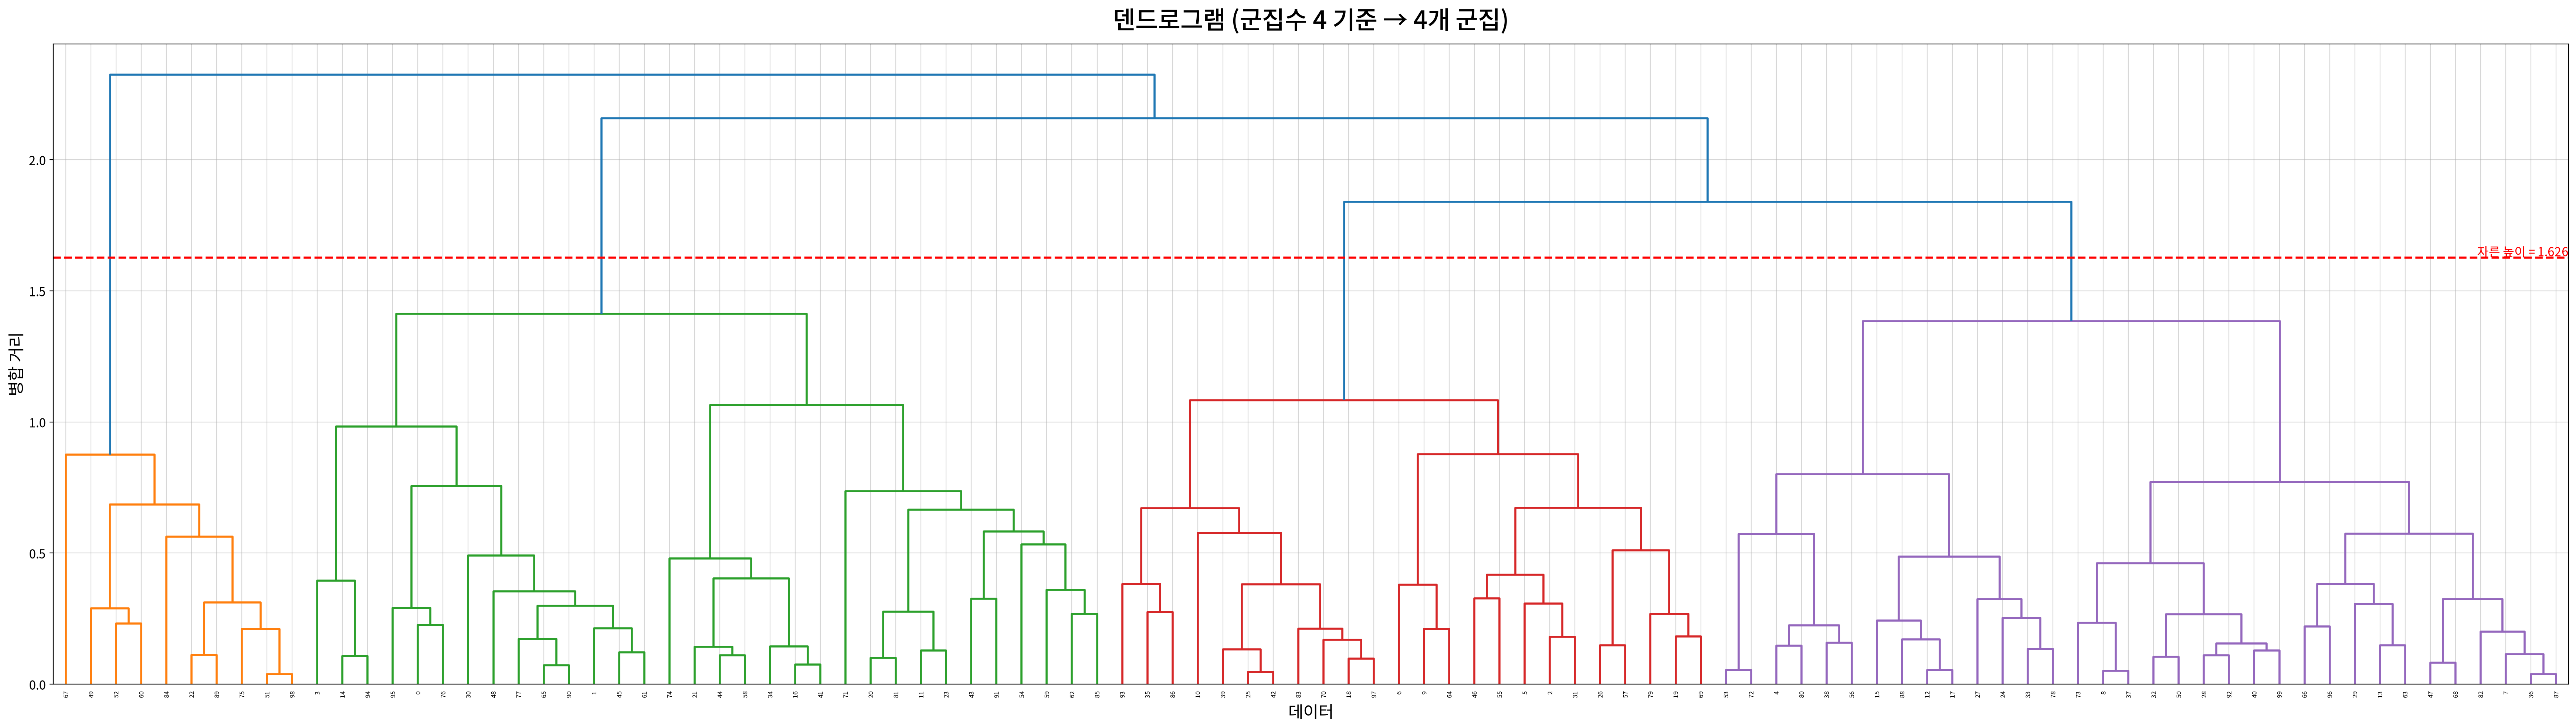

In [13]:
estimator, df = my_cluster.agglomerative(origin, k=4,
                        linkage="average",     # 두 덩어리의 모든 쌍의 평균 거리로 합친다
                        truncate_mode=None,    # 가지를 생략하지 않고 전체를 표시
                        leaf_rotation=90, leaf_font_size=6,
                        width=3500, height=1000, verbose=False)

> 연결 방법(`linkage`)을 바꾸면 합쳐지는 순서가 달라지므로 **나무의 모양도, 군집 결과도 달라진다.**
> `ward` 는 크기가 고른 덩어리를, `average` · `single` 은 한쪽으로 길게 이어지는 덩어리를 만드는 경향이 있다.